In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:
file_list = [
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_1.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_2.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_3.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_4.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_5.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_6.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_7.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_8.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_9.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_10.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_11.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_12.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_13.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_14.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_15.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_16.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_17.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_18.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_19.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_20.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_21.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_22.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_23.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_24.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_25.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_26.csv',
    r'C:\Users\franc\Desktop\GitHub\PSD_data\PSD_EEG_Subject_27.csv'
]

base_dir = r"C:\Users\franc\Desktop\GitHub\04-Test_3_Scalability_Analysis"
results_dir = os.path.join(base_dir, "results")
os.makedirs(results_dir, exist_ok=True)

log_path = os.path.join(results_dir, "scalability_log.txt")

def print_and_save(text, file):
    print(text)
    file.write(text + "\n")


In [3]:
# ===========================
# CONFIG
# ===========================
N_PARTS = 10
RANDOM_STATE = 42

EPOCHS = 150
TRAIN_BATCH_SIZE = 64

# Warm-up settings (not timed)
WARMUP_EPOCHS = 2
SYNC_PRED_BATCH = 32  # used to force sync after fit

In [4]:
# ===========================
# MODEL
# ===========================
def create_residual(input_layer, factors, dropout_pcg):
    out = Dense(factors, activation="relu")(input_layer)
    out = BatchNormalization()(out)
    out = Dropout(dropout_pcg)(out)

    out = Add()([out, input_layer])

    out = Dense(factors, activation="relu")(out)
    out = BatchNormalization()(out)
    out = Dropout(dropout_pcg)(out)
    return out

def create_model(input_dim, num_classes, factors=256, dropout_pcg=0.25):
    inp = Input(shape=(input_dim,))

    out = Dense(factors, activation="relu")(inp)
    out = BatchNormalization()(out)
    out = Dropout(dropout_pcg)(out)

    out1 = create_residual(out, factors, dropout_pcg)

    out = Concatenate()([out1, inp])
    out = Dense(num_classes, activation="softmax")(out)

    model = Model(inp, out)
    opt = tf.keras.optimizers.Adam(learning_rate=1e-3, epsilon=1e-14)
    model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])
    return model

In [5]:
# ===========================
# OVERSAMPLING
# ===========================
def oversample_balance(X_scaled: np.ndarray, y: np.ndarray, random_state=42):
    df = pd.DataFrame(X_scaled)
    df["Event Id"] = y

    counts = df["Event Id"].value_counts()
    max_n = counts.max()

    balanced = []
    for cls, cnt in counts.items():
        df_cls = df[df["Event Id"] == cls]
        if cnt < max_n:
            df_cls = resample(df_cls, replace=True, n_samples=max_n, random_state=random_state)
        balanced.append(df_cls)

    df_bal = pd.concat(balanced).sample(frac=1, random_state=random_state).reset_index(drop=True)
    Xb = df_bal.drop("Event Id", axis=1).values
    yb = df_bal["Event Id"].values
    return Xb, yb


In [6]:
# ===========================
# MAIN EXPERIMENT
# ===========================
with open(log_path, "w", encoding="utf-8") as f:

    # --- Load first file to get feature columns ---
    first_df = pd.read_csv(file_list[0])
    if "Event Id" not in first_df.columns:
        raise ValueError("Column 'Event Id' was not found in the CSV files.")
    feature_cols = [c for c in first_df.columns if c != "Event Id"]

    # --- Per-subject 80/20 split, then concatenate ---
    train_parts = []
    test_parts = []

    for fp in file_list:
        df = pd.read_csv(fp)
        if "Event Id" not in df.columns:
            raise ValueError("Column 'Event Id' was not found in the CSV files.")

        X_subj = df[feature_cols].astype(float)
        y_subj = df["Event Id"].values

        X_train_subj, X_test_subj, y_train_subj, y_test_subj = train_test_split(
            X_subj, y_subj,
            test_size=0.2,
            shuffle=True,
            stratify=y_subj,
            random_state=RANDOM_STATE
        )

        train_df = X_train_subj.copy()
        train_df["Event Id"] = y_train_subj
        test_df = X_test_subj.copy()
        test_df["Event Id"] = y_test_subj

        train_parts.append(train_df)
        test_parts.append(test_df)

    train_final = pd.concat(train_parts, ignore_index=True)
    test_final = pd.concat(test_parts, ignore_index=True)

    X_train_df = train_final[feature_cols].astype(float)
    y_train = train_final["Event Id"].values

    X_test_only = test_final[feature_cols].astype(float)
    y_test_only = test_final["Event Id"].values

    # --- Global class mapping ---
    classes_global = np.sort(np.unique(np.concatenate([y_train, y_test_only])))
    to_index = {c: i for i, c in enumerate(classes_global)}
    NUM_CLASSES = len(classes_global)

    y_test_idx = np.array([to_index[c] for c in y_test_only])

    print_and_save(f"Train rows (raw): {len(train_final)}", f)
    print_and_save(f"Test rows  (raw): {len(test_final)}", f)
    print_and_save(f"NUM_CLASSES: {NUM_CLASSES}", f)
    print_and_save("", f)

    # --- Split train into disjoint stratified parts ---
    skf = StratifiedKFold(n_splits=N_PARTS, shuffle=True, random_state=RANDOM_STATE)
    partition_list = []
    for _, (_, part_idx) in enumerate(skf.split(X_train_df, y_train), start=1):
        part_X = X_train_df.iloc[part_idx].copy()
        part_y = y_train[part_idx]
        part_df = part_X.copy()
        part_df["Event Id"] = part_y
        partition_list.append(part_df)

    results = []

    for k in range(1, N_PARTS + 1):
        print_and_save(f"\n===== k = {k} (P1..P{k}) =====", f)

        train_subset = pd.concat(partition_list[:k], ignore_index=True)
        X_train_sub = train_subset[feature_cols].astype(float)
        y_train_sub = train_subset["Event Id"].values

        # Fit scaler only on current training subset
        scaler = MinMaxScaler().fit(X_train_sub)
        X_train_scaled = scaler.transform(X_train_sub)
        X_test_scaled = scaler.transform(X_test_only)

        # Oversample to balance classes
        X_train_bal, y_train_bal = oversample_balance(X_train_scaled, y_train_sub, random_state=RANDOM_STATE)

        # Global one-hot encoding
        y_train_bal_idx = np.array([to_index[c] for c in y_train_bal])
        y_train_cat = to_categorical(y_train_bal_idx, num_classes=NUM_CLASSES)

        # Clear TF session to reduce cross-run interference
        tf.keras.backend.clear_session()
        model = create_model(input_dim=X_train_bal.shape[1], num_classes=NUM_CLASSES)

        # ---------------------------
        # Warm-up (NOT timed)
        # ---------------------------
        _ = model.fit(
            X_train_bal, y_train_cat,
            epochs=WARMUP_EPOCHS,
            batch_size=TRAIN_BATCH_SIZE,
            validation_split=0.0,
            callbacks=[],
            verbose=0,
            shuffle=True
        )

        # ---------------------------
        # Timed training (fixed epochs)
        # ---------------------------
        t0 = time.perf_counter()
        _ = model.fit(
            X_train_bal, y_train_cat,
            epochs=EPOCHS,
            batch_size=TRAIN_BATCH_SIZE,
            validation_split=0.0,
            callbacks=[],
            verbose=0,
            shuffle=True
        )

        # Force synchronization before stopping timer (important on GPU)
        _ = model.predict(
            X_train_bal[:SYNC_PRED_BATCH].astype(np.float32),
            batch_size=SYNC_PRED_BATCH,
            verbose=0
        )

        train_time_sec = time.perf_counter() - t0
        time_per_epoch = train_time_sec / EPOCHS

        # Quick performance report (acc + macro metrics)
        y_pred = model.predict(X_test_scaled, verbose=0)
        y_pred_idx = np.argmax(y_pred, axis=1)
        
        acc = accuracy_score(y_test_idx, y_pred_idx)
        f1m = f1_score(y_test_idx, y_pred_idx, average="macro")
        prec_m = precision_score(y_test_idx, y_pred_idx, average="macro", zero_division=0)
        rec_m  = recall_score(y_test_idx, y_pred_idx, average="macro", zero_division=0)
        
        print_and_save(f"train_rows_raw={len(train_subset)} | train_rows_bal={len(X_train_bal)}", f)
        print_and_save(f"Training time (fit): {train_time_sec:.3f} s | per-epoch: {time_per_epoch:.3f} s", f)
        print_and_save(
            f"Test Acc: {acc:.4f} | Macro-F1: {f1m:.4f} | Macro-Prec: {prec_m:.4f} | Macro-Rec: {rec_m:.4f}",
            f
        )
        
        results.append({
            "k_parts": k,
            "train_rows_raw": len(train_subset),
            "train_rows_bal": len(X_train_bal),
            "train_time_sec": train_time_sec,
            "test_acc": acc,
            "macro_f1": f1m,
            "macro_precision": prec_m,
            "macro_recall": rec_m
        })


    # Full results table in log
    res_df = pd.DataFrame(results)
    print_and_save("\n=== FULL RESULTS ===", f)
    print_and_save(res_df.to_string(index=False), f)

print(f"Saved log: {log_path}")



Train rows (raw): 33157
Test rows  (raw): 8316
NUM_CLASSES: 5


===== k = 1 (P1..P1) =====

train_rows_raw=3316 | train_rows_bal=6915
Training time (fit): 81.490 s | per-epoch: 0.543 s
Test Acc: 0.4271 | Macro-F1: 0.3991 | Macro-Prec: 0.3998 | Macro-Rec: 0.4009

===== k = 2 (P1..P2) =====
train_rows_raw=6632 | train_rows_bal=13825
Training time (fit): 143.883 s | per-epoch: 0.959 s
Test Acc: 0.5475 | Macro-F1: 0.5204 | Macro-Prec: 0.5302 | Macro-Rec: 0.5150

===== k = 3 (P1..P3) =====
train_rows_raw=9948 | train_rows_bal=20735
Training time (fit): 207.263 s | per-epoch: 1.382 s
Test Acc: 0.5957 | Macro-F1: 0.5790 | Macro-Prec: 0.5809 | Macro-Rec: 0.5805

===== k = 4 (P1..P4) =====
train_rows_raw=13264 | train_rows_bal=27645
Training time (fit): 266.649 s | per-epoch: 1.778 s
Test Acc: 0.6475 | Macro-F1: 0.6414 | Macro-Prec: 0.6356 | Macro-Rec: 0.6500

===== k = 5 (P1..P5) =====
train_rows_raw=16580 | train_rows_bal=34555
Training time (fit): 321.637 s | per-epoch: 2.144 s
Test Acc: 0.6

In [7]:
# ===========================
# ONE-SHOT INFERENCE TIMING
# (model from k = 10)
# ===========================

PRED_BATCH_SIZE = 32     # default Keras batch size
PRED_WARMUP = 5          # warm-up runs
PRED_RUNS = 30           # timing repetitions

# usa il test set (niente oversampling)
Xb = X_test_scaled[:PRED_BATCH_SIZE].astype(np.float32)

# ---- warm-up (non misurato) ----
for _ in range(PRED_WARMUP):
    _ = model.predict(Xb, batch_size=PRED_BATCH_SIZE, verbose=0)

# ---- GPU sync (se disponibile) ----
try:
    tf.experimental.sync_devices()
except Exception:
    pass

# ---- timing ----
times = []
for _ in range(PRED_RUNS):
    t0 = time.perf_counter()
    _ = model.predict(Xb, batch_size=PRED_BATCH_SIZE, verbose=0)
    try:
        tf.experimental.sync_devices()
    except Exception:
        pass
    times.append(time.perf_counter() - t0)

times = np.array(times)

print("=== Inference timing (k = 10 model) ===")
print(f"Batch size: {PRED_BATCH_SIZE}")
print(f"Mean predict time: {times.mean()*1e3:.3f} ms")
print(f"Std  predict time: {times.std()*1e3:.3f} ms")
print(f"Throughput: {PRED_BATCH_SIZE / times.mean():.2f} samples/s")


=== Inference timing (k = 10 model) ===
Batch size: 32
Mean predict time: 85.273 ms
Std  predict time: 9.670 ms
Throughput: 375.27 samples/s


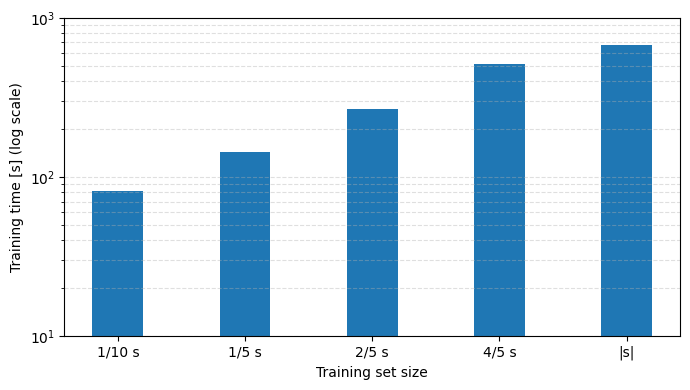

Saved plot: C:\Users\franc\Desktop\GitHub\04-Test_3_Scalability_Analysis\results\train_time_vs_k_parts_bar_logY.png


In [10]:
# ===========================
# BAR PLOT (LOG SCALE) WITH CUSTOM X LABELS
# ===========================

time_plot_path = os.path.join(results_dir, "train_time_vs_k_parts_bar_logY.png")

k_selected = [1, 2, 4, 8, 10]
res_df_sel = res_df[res_df["k_parts"].isin(k_selected)]

x_labels = ["1/10 s", "1/5 s", "2/5 s", "4/5 s", "|s|"]

# posizioni più compatte
x = np.arange(len(res_df_sel)) * 0.5

plt.figure(figsize=(7, 4))
plt.bar(
    x,
    res_df_sel["train_time_sec"],
    width=0.2
)

plt.yscale("log")
plt.ylim(bottom=1e1, top=1e3)

plt.xlabel("Training set size")
plt.ylabel("Training time [s] (log scale)")
plt.xticks(x, x_labels)

plt.grid(True, which="both", axis="y", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(time_plot_path, dpi=330)
plt.show()

print(f"Saved plot: {time_plot_path}")
